In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize


In [21]:
df = pd.read_csv("dataset_limpio.csv")
df.head()

,pt,eta,phi,charge,pos_x,pos_y,pos_z,particle_type,event_id
0,2.400150,0.739663,1.62212,1.0,0.000647,0.000633,0.039879,electron,22109111
1,1.314830,0.945947,-3.09573,1.0,0.000698,0.000623,-0.029173,track,22109111
2,1.384250,-1.488470,-2.93427,1.0,0.000703,0.000611,-0.029091,track,22109111
3,0.973126,0.576321,-2.91378,1.0,0.000704,0.000611,-0.020457,track,22109111
4,1.697150,1.373240,-2.92621,1.0,0.000701,0.000623,-0.020329,track,22109111


In [22]:
# Separar X y y
X = df[["pt", "eta", "phi", "charge", "pos_x", "pos_y", "pos_z"]]
y = df["particle_type"]

# Codificar la variable objetivo
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
classes = encoder.classes_

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
%%time
model = SGDClassifier(
    loss="log_loss",
    max_iter=2000,
    learning_rate="optimal",
    early_stopping=True,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_scaled, y_train)


CPU times: user 487 ms, sys: 1.06 s, total: 1.55 s
Wall time: 320 ms


SGDClassifier(early_stopping=True, loss='log_loss', max_iter=2000, n_jobs=-1,
              random_state=42)

=== Reporte de clasificación ===
              precision    recall  f1-score   support

    electron       0.00      0.00      0.00        37
        muon       0.00      0.00      0.00        99
      photon       0.41      0.35      0.38        63
       track       0.98      1.00      0.99      7528

    accuracy                           0.97      7727
   macro avg       0.35      0.34      0.34      7727
weighted avg       0.96      0.97      0.97      7727



/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


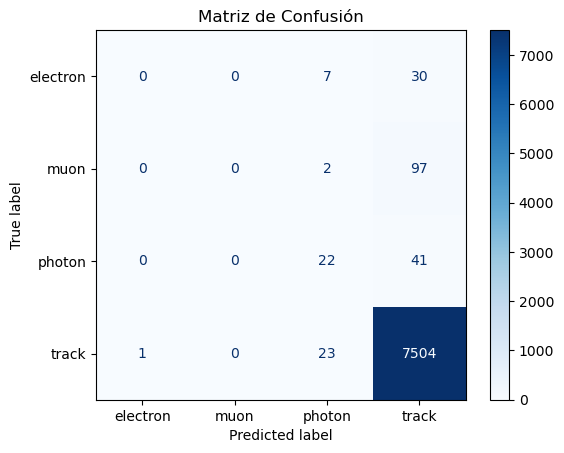

In [24]:
# Predicciones
y_pred = model.predict(X_test_scaled)

# Reporte
print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=classes))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión")
plt.show()

In [25]:
from sklearn.metrics import precision_score

precisiones = precision_score(y_test, y_pred, average=None)

for clase, prec in zip(classes, precisiones):
    print(f"Precisión para {clase}: {prec:.4f}")

Precisión para electron: 0.0000
Precisión para muon: 0.0000
Precisión para photon: 0.4074
Precisión para track: 0.9781


/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


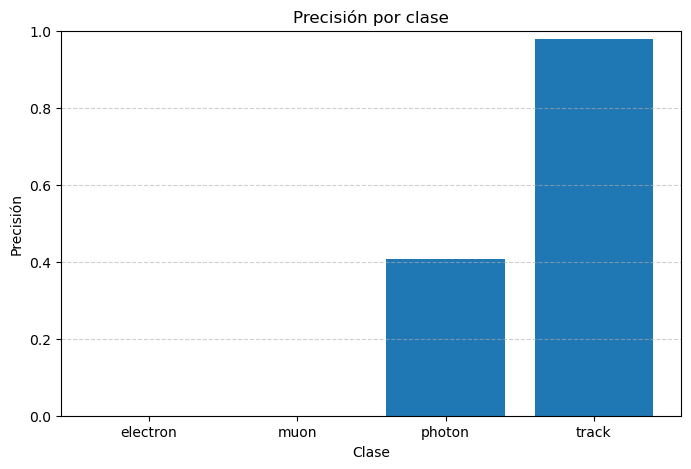

In [26]:
# Calcular precisión por clase
precisiones = precision_score(y_test, y_pred, average=None)

# Gráfica
plt.figure(figsize=(8,5))
plt.bar(classes, precisiones)
plt.ylabel("Precisión")
plt.xlabel("Clase")
plt.title("Precisión por clase")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

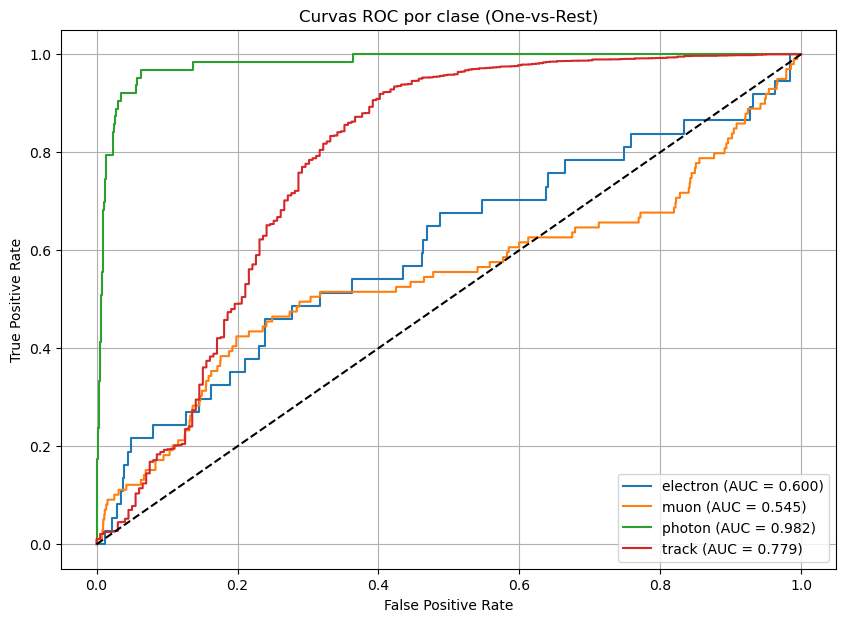

In [27]:
# Binarizar etiquetas para ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

# Obtener scores del modelo
y_scores = model.decision_function(X_test_scaled)

plt.figure(figsize=(10, 7))

for i, clase in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC por clase (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()


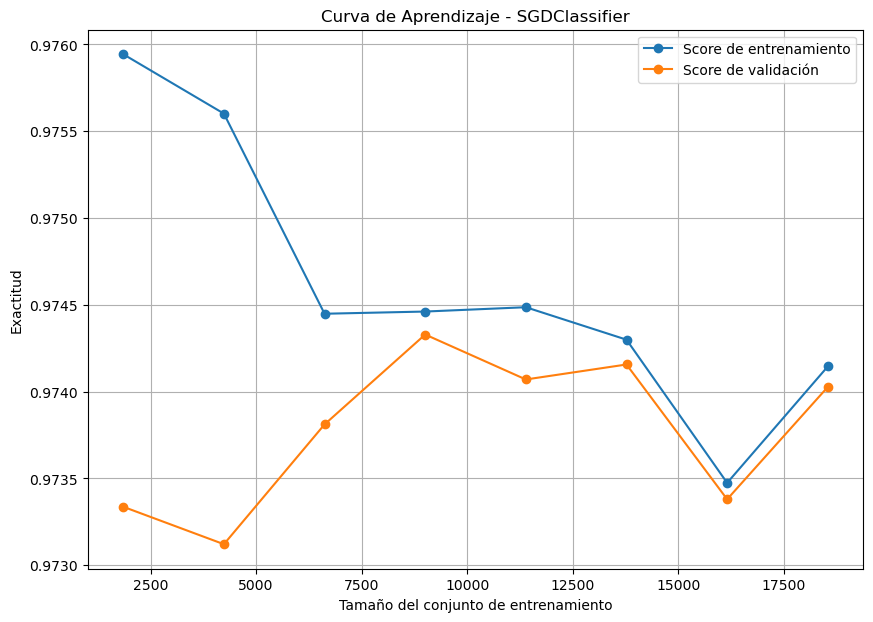

In [28]:
train_sizes, train_scores, test_scores = learning_curve(
    SGDClassifier(loss="log_loss", max_iter=2000, n_jobs=-1, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, marker="o", label="Score de entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Score de validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de Aprendizaje - SGDClassifier")
plt.legend()
plt.grid(True)
plt.show()

## SIN TRACK

In [29]:
df = pd.read_csv("dataset_limpio_notracks.csv")
df.head()

,pt,eta,phi,charge,pos_x,pos_y,pos_z,particle_type,event_id
0,2.400150,0.739663,1.622120,1.0,0.000647,0.000633,0.039879,electron,22109111
1,0.838852,-1.914380,2.947160,-1.0,0.000671,0.000501,-0.012415,muon,22109111
2,2.646500,-2.273300,0.817141,1.0,0.000773,0.000570,0.002240,muon,22109111
3,1.736600,-2.463090,-1.792570,1.0,0.002726,0.000183,-0.001184,muon,22109111
4,35.556000,0.005784,1.834000,0.0,0.000726,0.000609,-0.047592,photon,652620608


In [30]:
# Separar X y y
X = df[["pt", "eta", "phi", "charge", "pos_x", "pos_y", "pos_z"]]
y = df["particle_type"]

# Codificar la variable objetivo
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
classes = encoder.classes_

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
%%time
model = SGDClassifier(
    loss="log_loss",
    max_iter=2000,
    learning_rate="optimal",
    early_stopping=True,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_scaled, y_train)


CPU times: user 46.5 ms, sys: 9.91 ms, total: 56.4 ms
Wall time: 56.5 ms


SGDClassifier(early_stopping=True, loss='log_loss', max_iter=2000, n_jobs=-1,
              random_state=42)

=== Reporte de clasificación ===
              precision    recall  f1-score   support

    electron       0.43      0.16      0.24        37
        muon       0.76      0.84      0.80        99
      photon       0.62      0.75      0.68        63

    accuracy                           0.68       199
   macro avg       0.60      0.58      0.57       199
weighted avg       0.65      0.68      0.65       199



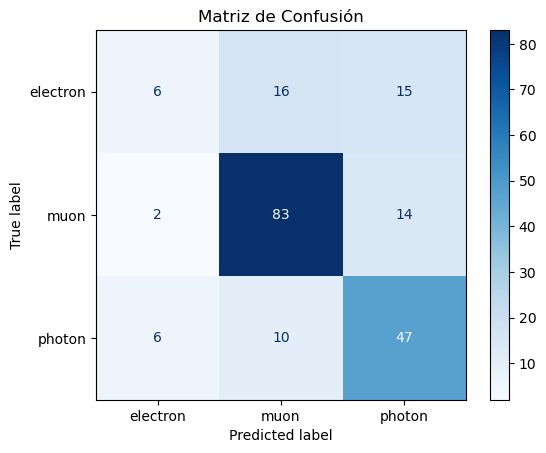

In [32]:
# Predicciones
y_pred = model.predict(X_test_scaled)

# Reporte
print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=classes))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión")
plt.show()

In [33]:
from sklearn.metrics import precision_score

precisiones = precision_score(y_test, y_pred, average=None)

for clase, prec in zip(classes, precisiones):
    print(f"Precisión para {clase}: {prec:.4f}")

Precisión para electron: 0.4286
Precisión para muon: 0.7615
Precisión para photon: 0.6184


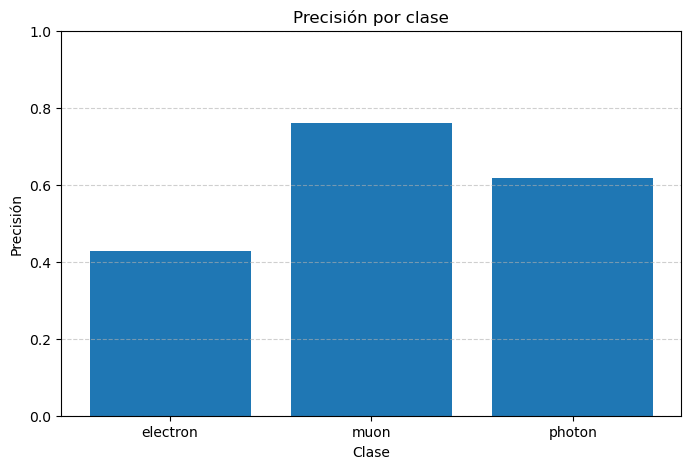

In [34]:
# Calcular precisión por clase
precisiones = precision_score(y_test, y_pred, average=None)

# Gráfica
plt.figure(figsize=(8,5))
plt.bar(classes, precisiones)
plt.ylabel("Precisión")
plt.xlabel("Clase")
plt.title("Precisión por clase")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

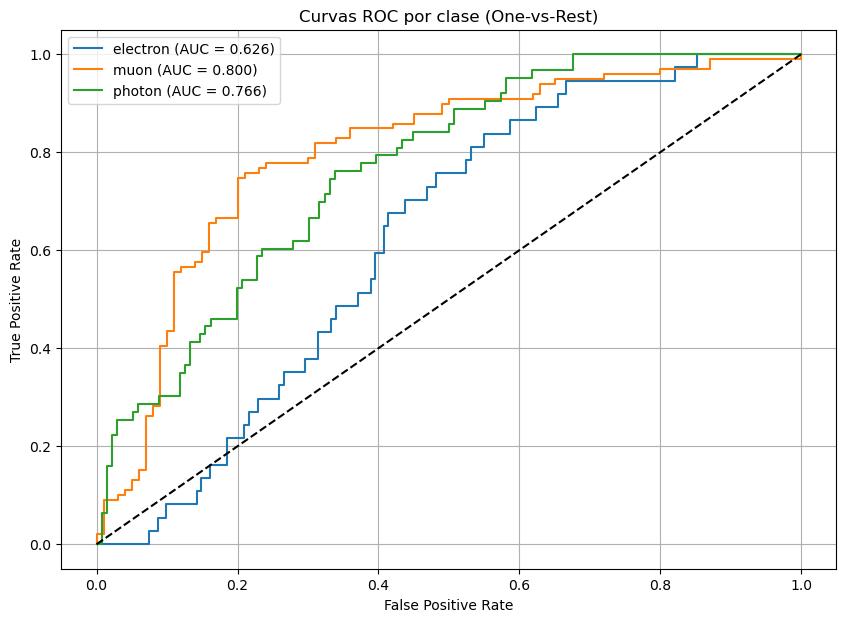

In [35]:
# Binarizar etiquetas para ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

# Obtener scores del modelo
y_scores = model.decision_function(X_test_scaled)

plt.figure(figsize=(10, 7))

for i, clase in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC por clase (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()


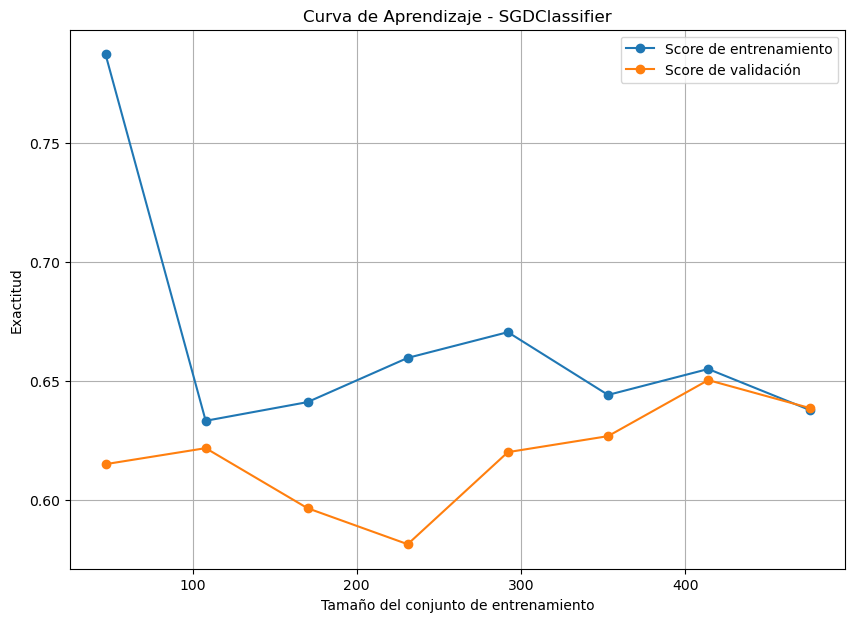

In [36]:
train_sizes, train_scores, test_scores = learning_curve(
    SGDClassifier(loss="log_loss", max_iter=2000, n_jobs=-1, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, marker="o", label="Score de entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Score de validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de Aprendizaje - SGDClassifier")
plt.legend()
plt.grid(True)
plt.show()